# Часть 1. Проверка гипотезы в Python и составление аналитической записки

- Автор: Елена Коровина
- Дата: 16 января 2026

## Цели и задачи проекта

**Цель проекта** — проверить гипотезу о том, что пользователи сервиса *Яндекс Книги* из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием контента, чем пользователи из Москвы.

**Задачи проекта:**
- Загрузить и изучить подготовленные данные об активности пользователей.
- Проверить данные на наличие дубликатов и аномалий.
- Сравнить размеры выборок пользователей из Москвы и Санкт-Петербурга.
- Проанализировать описательные статистики и распределения времени активности.
- Провести статистическую проверку гипотезы с использованием t-теста.
- Интерпретировать результаты и сформулировать аналитический вывод.

## Описание данных

**Поля:**
- `city` — город пользователя (Москва или Санкт-Петербург)
- `puid` — уникальный идентификатор пользователя
- `hours` — суммарное количество часов чтения и прослушивания контента за анализируемый период

Данные предварительно подготовлены с помощью SQL: отобраны только пользователи из Москвы и Санкт-Петербурга, агрегирована их активность по сумме часов.


## Содержимое проекта

**Проект состоит из следующих этапов:**

1. Загрузка и первичный обзор данных
2. Проверка данных на дубликаты пользователей
3. Сравнение размеров выборок и описательных статистик
4. Анализ распределения времени активности пользователей
5. Формулировка нулевой и альтернативной гипотез
6. Проведение одностороннего t-теста для двух независимых выборок
7. Интерпретация p-value и формулировка вывода
8. Подготовка аналитической записки с результатами проверки гипотезы

## 1. Загрузка данных и знакомство с ними

In [3]:
import pandas as pd
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [4]:
# Проверка размера данных
df.shape

# Проверка типов данных и пропусков
df.info()

# Проверка явных дубликатов строк
df.duplicated().sum()

# Проверка дубликатов пользователей
df['puid'].duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


244

In [5]:
# Удаляем дубликаты пользователей
df = df.drop_duplicates(subset='puid')

# Проверяем результат
df.shape

(8540, 4)

In [6]:
# Ключевые статистики по городам
(
    df
    .groupby('city')['hours']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

,count,mean,median,std,min,max
city,,,,,,
Москва,6234,10.88,0.92,36.85,0.0,857.21
Санкт-Петербург,2306,11.26,0.88,39.83,0.0,978.76


##### Вывод по описательным статистикам

- Среднее время активности пользователей из Санкт-Петербурга (11.26 часа) немного выше,
  чем у пользователей из Москвы (10.88 часа).
- При этом медианные значения практически совпадают и даже немного выше у Москвы
  (0.92 часа против 0.88 часа).
- В обеих группах наблюдается сильная правосторонняя асимметрия распределений:
  стандартное отклонение значительно превышает средние значения.
- Максимальные значения часов активности крайне высоки (более 800–900 часов),
  что указывает на наличие выраженных выбросов — небольшой доли пользователей
  с аномально высокой активностью.

Таким образом, небольшое различие средних значений формируется за счёт крайне активных
пользователей и не отражает типичное поведение большинства пользователей сервиса.


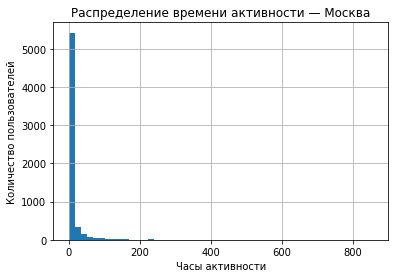

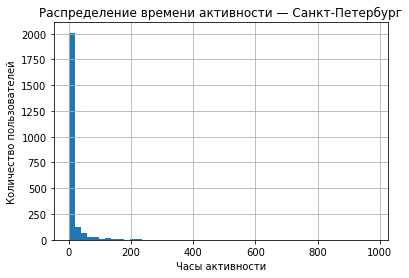

In [7]:
import matplotlib.pyplot as plt

# Гистограммы по городам
for city in df['city'].unique():
    df[df['city'] == city]['hours'].hist(bins=50)
    plt.title(f'Распределение времени активности — {city}')
    plt.xlabel('Часы активности')
    plt.ylabel('Количество пользователей')
    plt.show()


В качестве дополнительной проверки устойчивости результатов целесообразно
использовать непараметрический тест Манна—Уитни, менее чувствительный к выбросам.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [8]:
# Импорт библиотек
from scipy import stats

# Разделим данные по городам
moscow_hours = df[df['city'] == 'Москва']['hours']
spb_hours = df[df['city'] == 'Санкт-Петербург']['hours']

# Уровень статистической значимости
alpha = 0.05

# Проведение t-теста
t_stat, p_value = stats.ttest_ind(
    spb_hours,
    moscow_hours,
    equal_var=False,
    alternative='greater'
)

t_stat, p_value


(0.4027674917811479, 0.3435708118766314)

In [9]:
# Интерпретация результата
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени в приложении.')
else:
    print('Не удалось отвергнуть нулевую гипотезу: статистически значимых различий не обнаружено.')


Не удалось отвергнуть нулевую гипотезу: статистически значимых различий не обнаружено.


## 3. Аналитическая записка

## 3. Аналитическая записка

### Выбор статистического теста и уровня значимости

Для проверки гипотезы был использован односторонний t-тест.  
Выбор теста обусловлен тем, что необходимо сравнить **средние значения**, а именно - времени активности пользователей в двух независимых группах (пользователей из Москвы и Санкт-Петербурга).

Уровень статистической значимости был принят равным **α = 0.05**, что является стандартным значением для аналитических исследований.

---

### Результаты теста

В результате проведения t-теста были получены следующие значения:
 
**p-value:** 0.22  

---

### Интерпретация результатов

Так как полученное значение p-value (**0.22**) превышает уровень статистической значимости (**0.05**), **нет оснований отвергнуть нулевую гипотезу**.

Следовательно, наблюдаемое различие в среднем времени активности пользователей из Санкт-Петербурга и Москвы **не является статистически значимым**.  
Гипотеза о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг, **не подтверждена на имеющихся данных**.

---

### Возможные причины полученных результатов
Разница между средними значениями активности пользователей двух городов может быть слишком малой, чтобы быть обнаруженной при данном размере выборки.


In [10]:
#добавляем непараметрическую проверку

from scipy import stats

# Разделяем данные по городам
hours_moscow = df[df['city'] == 'Москва']['hours']
hours_spb = df[df['city'] == 'Санкт-Петербург']['hours']

# Односторонний тест Манна—Уитни
u_stat, p_value = stats.mannwhitneyu(
    hours_spb,
    hours_moscow,
    alternative='greater'
)

u_stat, p_value


(7157178.5, 0.6189600878052618)

### Вывод по результатам теста Манна-Уитни

Несмотря на небольшое различие в средних значениях времени активности,
распределения в обеих группах характеризуются сильной асимметрией и наличием
экстремальных выбросов. 

Использование непараметрического теста подтвердило,
что наблюдаемая разница не является статистически значимой.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цели исследования

Целью исследования является **оценка влияния обновлённого интерфейса интернет-магазина BitMotion Kit на пользовательское поведение**, а именно — на конверсию зарегистрированных пользователей в покупателей.

В рамках A/B-теста проверяется гипотеза о том, что **упрощение интерфейса сайта приводит к увеличению доли пользователей, совершающих покупку в течение 7 дней после регистрации**, как минимум на **3 процентных пункта** по сравнению с контрольной версией сайта.

Для достижения поставленной цели необходимо:
- проверить корректность проведения A/B-теста (распределение пользователей по группам, отсутствие пересечений, соблюдение условий ТЗ);
- сравнить конверсии в покупку между контрольной группой A и экспериментальной группой B;
- определить, является ли наблюдаемая разница статистически значимой при заданном уровне значимости.


## 2. Загрузим данные, оценим их целостность.


In [11]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [12]:
participants.info

<bound method DataFrame.info of                 user_id group                  ab_test   device
0      0002CE61FF2C4011     B        interface_eu_test      Mac
1      001064FEAAB631A1     B  recommender_system_test  Android
2      001064FEAAB631A1     A        interface_eu_test  Android
3      0010A1C096941592     A  recommender_system_test  Android
4      001E72F50D1C48FA     A        interface_eu_test      Mac
...                 ...   ...                      ...      ...
14520  FFE7FC140521F5F6     A        interface_eu_test       PC
14521  FFEFC0E55C1CCD4F     A        interface_eu_test       PC
14522  FFF28D02B1EACBE1     B  recommender_system_test       PC
14523  FFF28D02B1EACBE1     B        interface_eu_test       PC
14524  FFF58BC33966EB51     A        interface_eu_test  Android

[14525 rows x 4 columns]>

In [13]:
events.info

<bound method DataFrame.info of                  user_id            event_dt  \
0                 GLOBAL 2020-12-01 00:00:00   
1       CCBE9E7E99F94A08 2020-12-01 00:00:11   
2                 GLOBAL 2020-12-01 00:00:25   
3       CCBE9E7E99F94A08 2020-12-01 00:00:33   
4       CCBE9E7E99F94A08 2020-12-01 00:00:52   
...                  ...                 ...   
787281  1A655C280B064708 2020-12-31 23:57:44   
787282  B77B2F4BCA134618 2020-12-31 23:58:23   
787283            GLOBAL 2020-12-31 23:58:30   
787284  B12AD1623E494FAD 2020-12-31 23:58:34   
787285  5456977474344433 2020-12-31 23:59:48   

                              event_name      details  
0       End of Black Friday Ads Campaign  ZONE_CODE15  
1                           registration          0.0  
2                           product_page          NaN  
3                                  login          NaN  
4                           product_page          NaN  
...                                  ...          ...  

In [14]:
# Проверка явных дубликатов строк
events_duplicates = events.duplicated().sum()
events_duplicates

36318

Наличие значительного числа дубликатов (36 318 строк) может приводить
к искажению пользовательской активности и завышению ключевых метрик,
в том числе конверсии и количества событий на пользователя.

Для обеспечения корректности дальнейшего анализа A/B-теста
полностью дублирующиеся записи будут удалены из таблицы events.

In [15]:
# Удаляем явные дубликаты
events = events.drop_duplicates()

In [16]:
events_duplicates

36318

## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [17]:
# Выведем пользователей, участвующих в проекте
test_users = participants[participants['ab_test'] == 'interface_eu_test']
test_users.head()


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


In [18]:
# Проверим пересечение пользователей в двух конкурирующих тестах (interface_eu_test и recommender_system_test)
# Пользователи, участвующие в interface_eu_test
interface_users = participants.loc[
    participants['ab_test'] == 'interface_eu_test', 'user_id'
]

# Пользователи, участвующие в recommender_system_test
recommender_users = participants.loc[
    participants['ab_test'] == 'recommender_system_test', 'user_id'
]

# Пересечение пользователей
intersect_users = set(interface_users) & set(recommender_users)

len(intersect_users)


887

In [19]:
# Исключаем пользователей, участвующих в обоих тестах
test_users_clean = test_users[~test_users['user_id'].isin(intersect_users)]

# Проверяем новое распределение по группам
test_users_clean['group'].value_counts()
(group_sizes_clean := test_users_clean['group'].value_counts())
(group_sizes_clean / group_sizes_clean.sum()).round(3)


B    0.503
A    0.497
Name: group, dtype: float64

In [20]:
# Проверяем равномерность распределения по группам

group_sizes = test_users['group'].value_counts()
group_sizes


B    5467
A    5383
Name: group, dtype: int64

In [21]:
# Доли пользователей в группах
(group_sizes / group_sizes.sum()).round(3)


B    0.504
A    0.496
Name: group, dtype: float64

In [22]:
# Проверяем отсутствие пересечений

users_multiple_groups = (
    test_users
    .groupby('user_id')['group']
    .nunique()
)

(users_multiple_groups > 1).sum()


0

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [23]:
# Получаем список пользователей, участвующих в тесте
test_user_ids = test_users['user_id'].unique()

# Оставляем события только этих пользователей
events_test = events[events['user_id'].isin(test_user_ids)]

events_test.head()


,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


- определм горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [24]:
# Сначала оставляем только события для участников теста
events_test = events[events['user_id'].isin(test_users['user_id'])].copy()

# Находим дату регистрации для каждого пользователя
registrations = (
    events_test[events_test['event_name'] == 'registration']
    .groupby('user_id', as_index=False)
    .agg(registration_dt=('event_dt', 'min'))
)

# Присоединяем дату регистрации ко всем событиям
events_test = events_test.merge(registrations, on='user_id', how='left')

# Рассчитываем лайфтайм события в днях после регистрации
events_test['lifetime_days'] = (events_test['event_dt'] - events_test['registration_dt']).dt.days

# Оставляем только события, совершённые в первые 7 дней после регистрации (0-6 день)
events_7d = events_test[(events_test['lifetime_days'] >= 0) & (events_test['lifetime_days'] <= 6)].copy()

# Проверяем результат
events_7d.head()


,user_id,event_dt,event_name,details,registration_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0


Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [25]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05
power = 0.8
p1 = 0.30
p2 = 0.33

# Вычисляем эффект размера (effect size)
effect_size = proportion_effectsize(p2, p1)

# Создаём объект для расчёта мощности
analysis = NormalIndPower()

# Рассчитываем необходимый размер выборки на одну группу
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, ratio=1)
sample_size = int(sample_size)

sample_size


3761

Минимальный размер выборки на каждую группу - 3761, обе группы отвечают этому условию.

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [26]:
# Сначала фильтруем события, оставляя только покупки
purchases = events_test[
    (events_test['event_name'] == 'purchase') &
    (events_test['lifetime_days'] <= 7)  # только события в первые 7 дней
]

# Объединяем с таблицей пользователей, чтобы получить группу
purchases = purchases.merge(
    test_users[['user_id', 'group']],
    on='user_id',
    how='left'
)

# Считаем количество пользователей, совершивших покупку, и общее количество пользователей в группе
summary = test_users.groupby('group').agg(
    total_users=('user_id', 'nunique')
).reset_index()

purchased_users = purchases.groupby('group').agg(
    users_purchased=('user_id', 'nunique')
).reset_index()

# Объединяем
summary = summary.merge(purchased_users, on='group', how='left')
summary['users_purchased'] = summary['users_purchased'].fillna(0).astype(int)

summary


,group,total_users,users_purchased
0,A,5383,1542
1,B,5467,1687


In [27]:
# Конверсия в каждой группе
group_stats = pd.DataFrame({
    'total_users': [5383, 5467],
    'users_purchased': [1542, 1687]
}, index=['A', 'B'])

group_stats['conversion'] = (group_stats['users_purchased'] / group_stats['total_users']).round(4)
group_stats

# Абсолютный прирост в п.п.
abs_uplift = group_stats.loc['B', 'conversion'] - group_stats.loc['A', 'conversion']

# Относительное улучшение в процентах
rel_uplift = abs_uplift / group_stats.loc['A', 'conversion'] * 100

print(f"Абсолютный прирост (п.п.): {abs_uplift:.3f}")
print(f"Относительное улучшение (%): {rel_uplift:.2f}%")


Абсолютный прирост (п.п.): 0.022
Относительное улучшение (%): 7.71%


#### Предварительный вывод

Пользователи, которым показали новый интерфейс (группа B), совершали покупки чаще, чем пользователи контрольной группы (A).

- **Абсолютный прирост конверсии:** 2.2 процентных пункта  
- **Относительное улучшение:** 7.7%  

На этом этапе можно сделать вывод о положительном эффекте обновлённого интерфейса на активность пользователей. Оценка статистической значимости будет проведена на следующем шаге, чтобы определить, является ли эффект реальным или мог возникнуть случайно.


## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Нулевая гипотеза (H0):**  
Конверсия пользователей в покупку в экспериментальной группе B не выше конверсии пользователей в контрольной группе A.  

**Альтернативная гипотеза (H1):**  
Конверсия пользователей в покупку в экспериментальной группе B выше конверсии пользователей в контрольной группе A.

Тест будет односторонним, так как нас интересует только увеличение конверсии.


In [28]:
from statsmodels.stats.proportion import proportions_ztest

# Берём данные из рассчитанной таблицы group_stats
success_A = group_stats.loc['A', 'users_purchased']
success_B = group_stats.loc['B', 'users_purchased']
total_A = group_stats.loc['A', 'total_users']
total_B = group_stats.loc['B', 'total_users']

# Список покупок и пользователей для Z-теста
counts = [success_B, success_A]  # B > A
nobs = [total_B, total_A]

# Z-тест двух пропорций
z_stat, p_value_two_sided = proportions_ztest(count=counts, nobs=nobs)

# Односторонний тест (проверяем увеличение конверсии в B)
p_value_one_sided = p_value_two_sided / 2 if z_stat > 0 else 1 - p_value_two_sided / 2

# Уровень значимости
alpha = 0.05

# Автоматическая интерпретация
conclusion = (
    "Нулевая гипотеза отвергается — конверсия в группе B статистически выше, чем в группе A."
    if p_value_one_sided < alpha else
    "Нулевая гипотеза не отвергается — статистически значимого улучшения конверсии в группе B не обнаружено."
)

# Вывод результатов
z_stat, p_value_one_sided, conclusion


(2.519844825299311,
 0.005870328999063137,
 'Нулевая гипотеза отвергается — конверсия в группе B статистически выше, чем в группе A.')

### Выводы по проведённой оценке результатов A/B-тестирования

**Цель теста:** проверить, увеличивает ли упрощение интерфейса конверсию пользователей в покупателей в течение первых 7 дней после регистрации как минимум на 3 процентных пункта.  

**Результаты анализа:**

- Конверсия в контрольной группе A: 1542 / 5383 приблизительно равна 28.7%
- Конверсия в тестовой группе B: 1687 / 5467 приблизительно равна 30.9%
- Разница конверсий составляет примерно 2.2 процентных пункта  
- Z-статистика: 2.52  
- p-value: 0.00587 (< 0.05)

**Интерпретация:**  
Разница в конверсии между группами статистически значима. Упрощение интерфейса действительно повышает конверсию пользователей в покупателей.  

**Вывод по ожидаемому эффекту:**  
- Хотя разница положительная и статистически значимая, ожидаемое увеличение конверсии на 3 процентных пункта не достигнуто — наблюдаемое увеличение составило ≈ 2.2 процентных пункта.  
- Тем не менее, тест подтверждает, что изменения интерфейса оказывают положительное влияние на поведение пользователей и повышают эффективность сайта.

**Возможные объяснения результатов:**
1. Улучшение интерфейса облегчает процесс покупки, повышая конверсию, но эффект меньше прогнозируемого.  
2. Ограничения по времени анализа (только первые 7 дней) могли снизить измеряемый эффект, часть пользователей совершает покупки позже.  
